# Is the average Metal song longer than the average pop song?

In [61]:
import requests
import random
import seaborn
import pandas
import numpy as np
import matplotlib.pyplot as plt

In [62]:
SPOTIFY_CLIENT_ID = "b429fff2e83d429f8d8e8b40688a8943"
SPOTIFY_CLIENT_SECRET = "b97ae7c0e2724d0783e54ffd9c9bbfdf"

auth_response = requests.post('https://accounts.spotify.com/api/token', {
    'grant_type': 'client_credentials',
    'client_id': SPOTIFY_CLIENT_ID,
    'client_secret': SPOTIFY_CLIENT_SECRET,
})

auth_data = auth_response.json()
access_token = auth_data['access_token']

headers = {
    'Authorization': f'Bearer {access_token}'
}

In [63]:
def callAPI(query):
    all_tracks = []

    for i in range(20):  # 20 requests * 50 tracks = 1000
        offset = i * 50

        response = requests.get(
            "https://api.spotify.com/v1/search",
            headers=headers,
            params={
                "q": query,
                "type": "track",
                "limit": 50,
                "offset": offset
            }
        )

        if response.status_code != 200:
            print("Error:", response.status_code, response.text)
            break

        data = response.json()
        items = data["tracks"]["items"]

        # If Spotify runs out of results early
        if not items:
            break

        all_tracks.extend(items)  # append all 50 tracks

    return all_tracks

In [ ]:
metTracks = callAPI('metal')

In [ ]:
popTracks = callAPI('pop')

In [ ]:
popTracks = popTracks[:len(popTracks)-len(popTracks)%20]
metTracks = metTracks[:len(popTracks)]

In [ ]:
metTracks = pandas.DataFrame(metTracks)
popTracks = pandas.DataFrame(popTracks)

In [ ]:
metMeans = []
popMeans = []
for i in range(popTracks.shape[0] // 20):
    metBlock = metTracks.iloc[i*20 : (i+1)*20]["duration_ms"].astype(int)
    metMeans.append(metBlock.mean())

    popBlock = popTracks.iloc[i*20 : (i+1)*20]["duration_ms"].astype(int)
    popMeans.append(popBlock.mean())

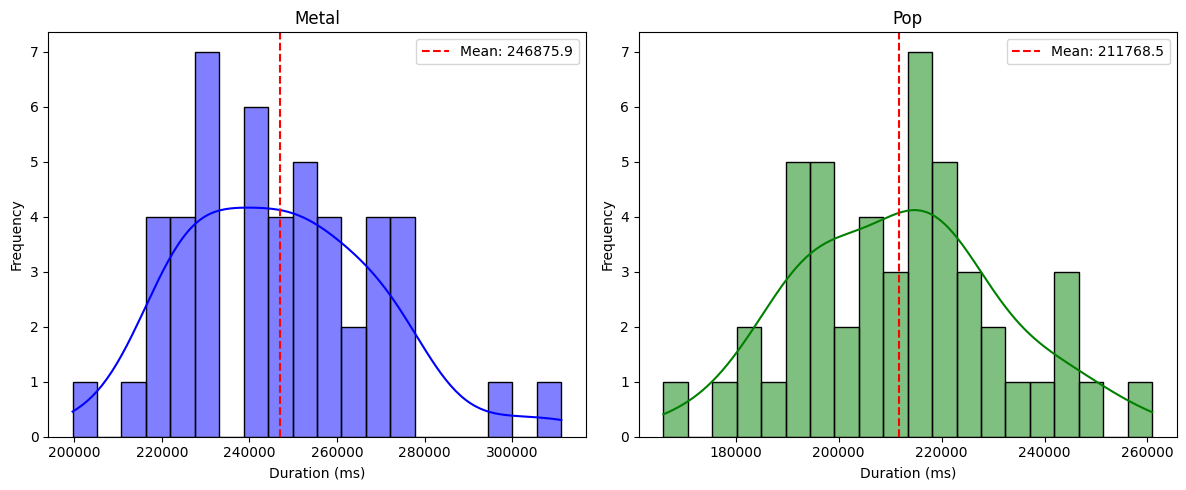

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Histogram for metMeans
seaborn.histplot(metMeans, bins=20, kde=True, ax=axes[0], color='blue')
mean_met = float(np.mean(metMeans))
axes[0].axvline(mean_met, color='red', linestyle='--', label=f"Mean: {mean_met:.1f}")
axes[0].set_title("Metal")
axes[0].set_xlabel("Duration (ms)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Histogram for popMeans
seaborn.histplot(popMeans, bins=20, kde=True, ax=axes[1], color='green')
mean_pop = float(np.mean(popMeans))
axes[1].axvline(mean_pop, color='red', linestyle='--', label=f"Mean: {mean_pop:.1f}")
axes[1].set_title("Pop")
axes[1].set_xlabel("Duration (ms)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
metSE = np.std(metMeans, ddof=1)/(20**0.5)
popSE = np.std(popMeans, ddof=1)/(20**0.5)
print(f"Metal Standard Error: {metSE}ms\nPop Standard Error: {popSE}ms")

Metal Standard Error: 4964.6629622770215ms
Pop Standard Error: 4495.630796987698ms


In [ ]:
metConfidenceInterval = [float(mean_met-1.96*metSE), float(mean_met+1.96*metSE)]
popConfidenceInterval = [float(mean_pop-1.96*popSE), float(mean_pop+1.96*popSE)]
print(f"Metal Confidence Interval: {metConfidenceInterval}ms\nPop Confidence Interval: {popConfidenceInterval}ms")

Metal Confidence Interval: [237145.2033022704, 256606.68211439633]ms
Pop Confidence Interval: [202957.06572123745, 220579.9384454292]ms


Based on the means alone it is clear that Metal songs are, on average, longer than pop songs. The 95% confidence intervals do not overlap indicating that the difference in mean durations is statistically significant. The graphs also indicate that metal songs are longer than pop songs on average.